<a href="https://colab.research.google.com/github/RajolKumar2003/RajolKumar2003/blob/main/LARGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell imports all the necessary Python libraries for data manipulation, analysis, and visualization, including `pandas` and `numpy`.

In [ ]:
import pandas as pd
import numpy as np

This cell mounts Google Drive to access files stored in your Drive, which is necessary for loading the dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This cell defines the file path for the dataset and then prints it to confirm the correct path is being used.

In [ ]:
file_path = '/content/drive/MyDrive/02-15-2018.csv'

print("Dataset path:")
print(file_path)

Dataset path:
/content/drive/MyDrive/02-15-2018.csv


This cell loads the dataset from the specified CSV file path into a pandas DataFrame. It uses `low_memory=False` to prevent mixed type warnings for large datasets.

In [ ]:
print("Loading dataset...")

df = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset loaded successfully.")

Loading dataset...
Dataset loaded successfully.


This cell displays the first few rows of the DataFrame, providing a quick overview of the data's structure and content.

In [ ]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,15/02/2018 08:25:18,112641158,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320579.0,7.042784e+02,56321077,56320081,Benign
1,22,6,15/02/2018 08:29:05,37366762,14,12,2168,2993,712,0,...,32,1024353.0,649038.754495,1601183,321569,11431221.0,3.644991e+06,15617415,8960247,Benign
2,47514,6,15/02/2018 08:29:42,543,2,0,64,0,64,0,...,32,0.0,0.000000,0,0,0.0,0.000000e+00,0,0,Benign
3,0,0,15/02/2018 08:28:07,112640703,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320351.5,3.669884e+02,56320611,56320092,Benign
4,0,0,15/02/2018 08:30:56,112640874,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320437.0,7.198347e+02,56320946,56319928,Benign


This cell lists all column names in the DataFrame, which is useful for understanding the available features and for subsequent data manipulation.

In [ ]:
df.columns.tolist()

['Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd B

This cell prints a summary of the DataFrame, including data types, non-null values, and memory usage. It helps in identifying missing values and incorrect data types.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

This cell removes the 'Timestamp' column from the DataFrame, as it might not be relevant for the anomaly detection task or can be handled separately if time-series analysis is intended.

In [ ]:
df.drop('Timestamp', axis=1, inplace=True)
print("'Timestamp' column removed successfully.")

'Timestamp' column removed successfully.


This cell calculates and displays the count of each unique value in the 'Label' column, providing insight into the distribution of benign and attack samples.

In [ ]:
df['Label'].value_counts()

,count
Label,
Benign,996077
DoS attacks-GoldenEye,41508
DoS attacks-Slowloris,10990


This cell generates a pie chart to visualize the distribution of different attack labels in the dataset. This helps to understand the class imbalance.

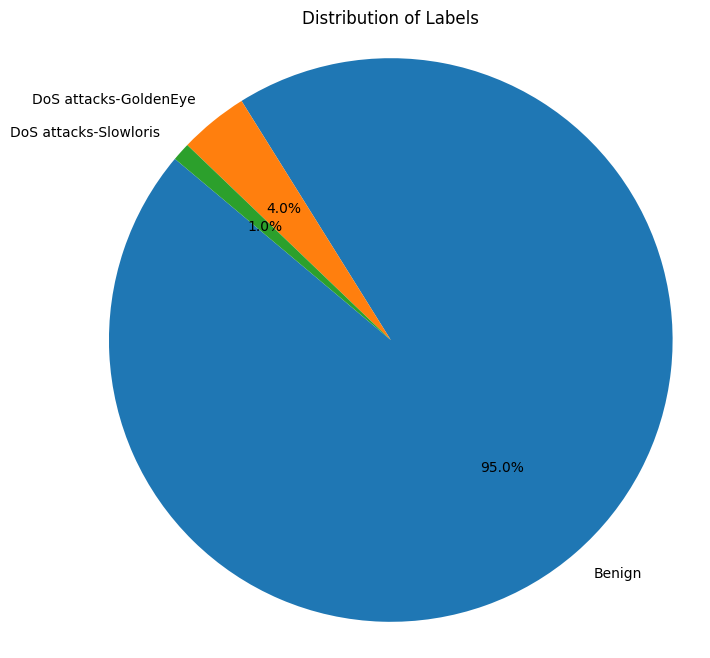

In [ ]:
import matplotlib.pyplot as plt

label_counts = df['Label'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This cell filters out rows labeled 'DoS attacks-Slowloris' from the DataFrame, indicating a decision to focus on specific types of attacks or to clean up less relevant data.

In [ ]:
initial_rows = len(df)
df = df[df['Label'] != 'DoS attacks-Slowloris']
removed_rows = initial_rows - len(df)
print(f"Removed {removed_rows} rows labeled 'DoS attacks-Slowloris'.")
print(f"New DataFrame shape: {df.shape}")

Removed 10990 rows labeled 'DoS attacks-Slowloris'.
New DataFrame shape: (1037585, 79)


This cell generates an updated pie chart showing the distribution of labels after removing the 'DoS attacks-Slowloris' category, including both counts and percentages for clarity.

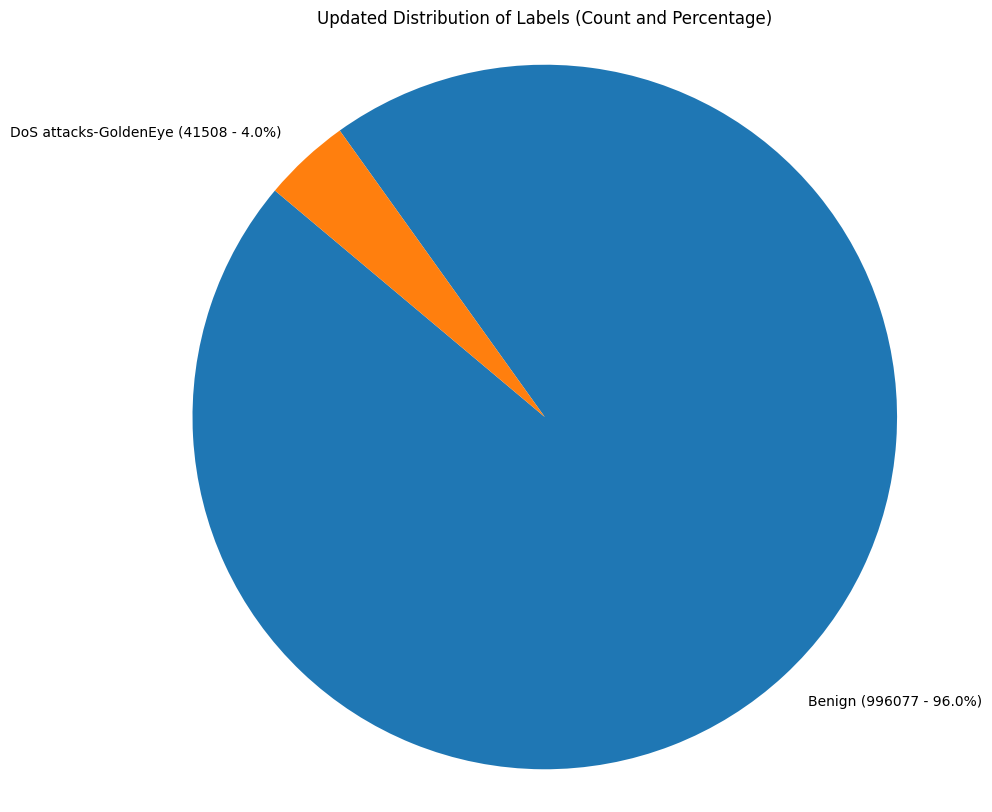

In [ ]:
import matplotlib.pyplot as plt

label_distribution = df['Label'].value_counts()
percentage_distribution = (label_distribution / len(df)) * 100

# Create labels with both count and percentage
labels = [f'{label} ({count} - {percentage:.1f}%)' for label, count, percentage in zip(label_distribution.index, label_distribution.values, percentage_distribution.values)]

plt.figure(figsize=(10, 10))
plt.pie(label_distribution, labels=labels, autopct='', startangle=140, pctdistance=0.85)
plt.title('Updated Distribution of Labels (Count and Percentage)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This cell checks for duplicate rows in the DataFrame and reports their count and percentage relative to the total number of rows. This is an important step in data cleaning.

In [ ]:
duplicate_rows = df.duplicated().sum()
total_rows = len(df)
duplicate_percentage = (duplicate_rows / total_rows) * 100

print(f"Number of duplicate rows: {duplicate_rows}")
print(f"Total number of rows: {total_rows}")
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")

Number of duplicate rows: 162835
Total number of rows: 1037585
Percentage of duplicate rows: 15.69%


This cell displays the actual duplicate records found in the DataFrame. Examining these can provide insights into potential data collection or recording issues.

In [ ]:
print("Duplicate records:")
duplicate_records = df[df.duplicated()]
display(duplicate_records)

Duplicate records:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
12290,80,6,1968873,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
13026,80,6,1947540,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
13146,80,6,9003609,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,9003609.0,0.0,9003609,9003609,DoS attacks-GoldenEye
13392,80,6,9000561,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,9000561.0,0.0,9000561,9000561,DoS attacks-GoldenEye
14374,80,6,1954456,2,0,0,0,0,0,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048478,80,6,113,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048488,443,6,142,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048490,80,6,97,2,0,0,0,0,0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048553,443,6,219,3,0,77,0,46,0,25.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


This cell removes all duplicate rows from the DataFrame, ensuring that each record is unique and preventing biases in analysis or model training.

In [ ]:
print("Removing duplicate rows...")
df.drop_duplicates(inplace=True)
print(f"DataFrame now has {len(df)} distinct rows.")

Removing duplicate rows...
DataFrame now has 874750 distinct rows.


This cell identifies and displays columns that still contain missing values after initial processing, highlighting areas that need further imputation or handling.

In [ ]:
print("Missing values in the DataFrame:")
missing_values = df.isnull().sum()
# Display only columns with missing values
display(missing_values[missing_values > 0])


Missing values in the DataFrame:


,0
Flow Byts/s,4759


This cell calculates and displays the percentage of missing values for each column, providing a more intuitive understanding of the extent of missing data.

In [ ]:
print("Percentage of missing values in the DataFrame:")
missing_percentage = (missing_values / len(df)) * 100
# Display only columns with missing values and their percentages
display(missing_percentage[missing_percentage > 0])

Percentage of missing values in the DataFrame:


,0
Flow Byts/s,0.544041


This cell checks for missing values in the 'Flow Byts/s' column, identifies the labels associated with these missing values, and then imputes them using the median 'Flow Byts/s' value specific to each label.

In [ ]:
# Check labels associated with missing 'Flow Byts/s' values
print("Labels for rows with missing 'Flow Byts/s' values:")
display(df[df['Flow Byts/s'].isnull()]['Label'].value_counts())

# Calculate median 'Flow Byts/s' for each label
median_flow_byts_per_label = df.groupby('Label')['Flow Byts/s'].median()
print("\nMedian 'Flow Byts/s' for each label:")
display(median_flow_byts_per_label)

# Impute missing 'Flow Byts/s' values based on the median of their respective label
for label, median_value in median_flow_byts_per_label.items():
    df.loc[(df['Label'] == label) & (df['Flow Byts/s'].isnull()), 'Flow Byts/s'] = median_value

print("\nMissing values in 'Flow Byts/s' imputed successfully.")
# Verify that there are no more missing values in 'Flow Byts/s'
print("\nMissing values after imputation:")
display(df['Flow Byts/s'].isnull().sum())


Labels for rows with missing 'Flow Byts/s' values:


,count
Label,
Benign,4759



Median 'Flow Byts/s' for each label:


,Flow Byts/s
Label,
Benign,1035.553257
DoS attacks-GoldenEye,122.482045



Missing values in 'Flow Byts/s' imputed successfully.

Missing values after imputation:


np.int64(0)

This cell checks for and handles infinite values in the numeric columns of the DataFrame. It replaces them with NaN and then imputes these NaNs using label-wise medians, similar to the handling of other missing values.

In [ ]:
print("Checking for and handling infinite values...")

# Identify numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Check for infinite values in numeric columns
inf_mask = df[numeric_cols].isin([np.inf, -np.inf]).any(axis=1)

if inf_mask.any():
    print("\nRows with infinite values detected. Displaying 'Label' distribution for these rows:")
    # Display value counts of 'Label' for rows with infinite values
    display(df.loc[inf_mask, 'Label'].value_counts())

    # Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Identify columns that now have NaN values (originally Inf)
    missing_from_inf_cols = df.columns[df.isnull().any()].tolist()
    missing_from_inf_cols = [col for col in missing_from_inf_cols if col in numeric_cols] # Only consider numeric cols for imputation

    if missing_from_inf_cols:
        print("\nColumns with NaN values (originally Inf) identified:")
        print(missing_from_inf_cols)

        # Impute these new NaN values with the median of their respective columns, grouped by 'Label'
        print("\nImputing NaN values (originally Inf) with median, grouped by 'Label'...")
        for col in missing_from_inf_cols:
            # Calculate median grouped by 'Label'
            median_by_label = df.groupby('Label')[col].transform('median')
            # Fill NaN values using the calculated median specific to each label
            df.loc[:, col] = df.loc[:, col].fillna(median_by_label)
            print(f"  - Imputed column '{col}' with label-wise medians.")
        print("\nInfinite values handled and imputed with label-wise medians successfully.")
    else:
        print("No columns had infinite values that turned into NaNs.")
else:
    print("No infinite values found in the DataFrame.")

# Verify that there are no more missing values introduced by Inf handling
print("\nRemaining missing values after handling Inf:")
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if not remaining_missing.empty:
    display(remaining_missing)
else:
    print("No remaining missing values.")

Checking for and handling infinite values...

Rows with infinite values detected. Displaying 'Label' distribution for these rows:


,count
Label,
Benign,7712



Columns with NaN values (originally Inf) identified:
['Flow Byts/s', 'Flow Pkts/s']

Imputing NaN values (originally Inf) with median, grouped by 'Label'...
  - Imputed column 'Flow Byts/s' with label-wise medians.
  - Imputed column 'Flow Pkts/s' with label-wise medians.

Infinite values handled and imputed with label-wise medians successfully.

Remaining missing values after handling Inf:
No remaining missing values.


This cell imports additional libraries (`os`, `gc`, `json`, `time`, `warnings`, `traceback`) that are crucial for the subsequent anomaly detection pipeline, including managing system resources and handling errors.

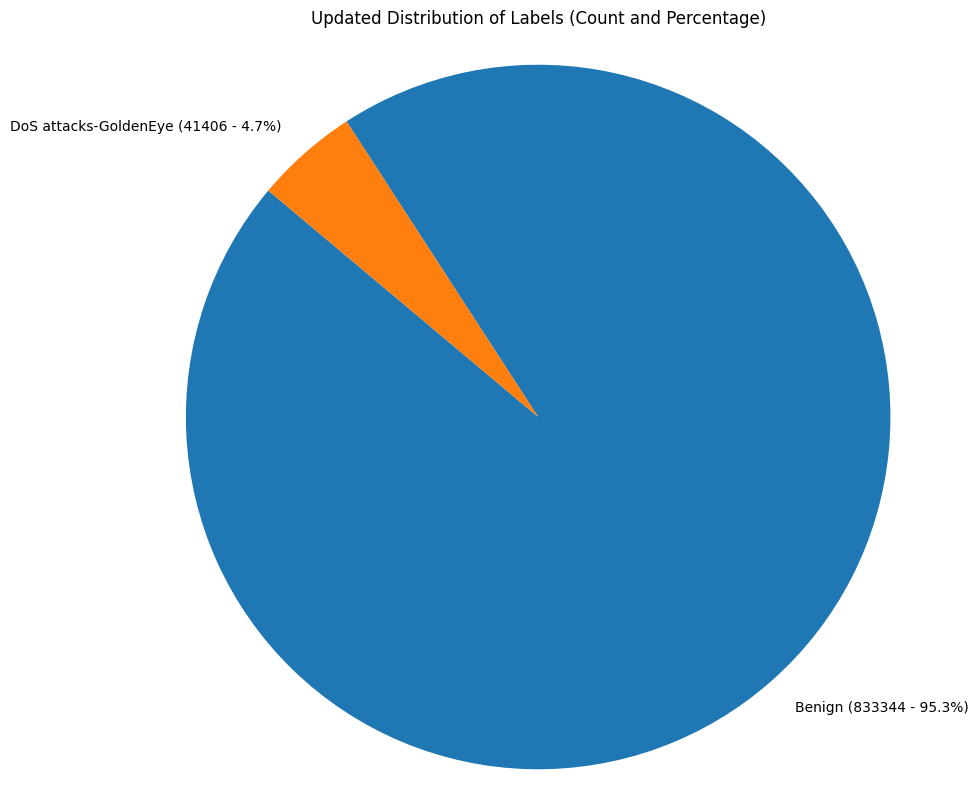

In [ ]:
import matplotlib.pyplot as plt

label_distribution = df['Label'].value_counts()
percentage_distribution = (label_distribution / len(df)) * 100

# Create labels with both count and percentage
labels = [f'{label} ({count} - {percentage:.1f}%)' for label, count, percentage in zip(label_distribution.index, label_distribution.values, percentage_distribution.values)]

plt.figure(figsize=(10, 10))
plt.pie(label_distribution, labels=labels, autopct='', startangle=140, pctdistance=0.85)
plt.title('Updated Distribution of Labels (Count and Percentage)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This cell defines a function to split a DataFrame into features (X) and labels (y), converting the 'Label' column into a binary representation (1 for attack, 0 for benign).

In [ ]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42

# Separate benign and attack records from the main DataFrame
benign_records = df[df['Label'] == 'Benign'].copy()
attack_records_goldeneye = df[df['Label'] == 'DoS attacks-GoldenEye'].copy()

print("==================================================")
print("TEST DATA CREATION - BENIGN SAMPLES")
print("==================================================")

N_total_test_size = 50000 # Total size for each test dataset

# Calculate required benign and anomaly counts for each anomaly rate
# For 0.2% anomaly:
N_anomaly_02 = round(N_total_test_size * 0.002) # 0.2% of total
N_benign_02 = N_total_test_size - N_anomaly_02 # 49900

# For 1% anomaly:
N_anomaly_1 = round(N_total_test_size * 0.01) # 1% of total
N_benign_1 = N_total_test_size - N_anomaly_1 # 49500

# For 5% anomaly:
N_anomaly_5 = round(N_total_test_size * 0.05) # 5% of total
N_benign_5 = N_total_test_size - N_anomaly_5 # 47500

# To ensure "benign data should be same" in the sense of hierarchy (smaller subsets are part of larger),
# we need to sample the largest required benign set first.
max_benign_samples_for_test = max(N_benign_02, N_benign_1, N_benign_5) # This will be 49900

# Sample the largest required number of benign samples for the test sets from the available benign records
common_test_benign_pool_sampled = benign_records.sample(n=max_benign_samples_for_test, random_state=RANDOM_STATE)
common_test_benign_pool_original_indices = common_test_benign_pool_sampled.index

# Create the hierarchical benign test sets. These will be subsets of the common_test_benign_pool
# To ensure 'sameness', we take ordered slices.
test_benign_02_percent = common_test_benign_pool_sampled.reset_index(drop=True) # 49900 samples
test_benign_1_percent = test_benign_02_percent.iloc[:N_benign_1].copy().reset_index(drop=True) # 49500 samples
test_benign_5_percent = test_benign_1_percent.iloc[:N_benign_5].copy().reset_index(drop=True) # 47500 samples

print(f"Benign test set for 0.2% attacks ({N_benign_02} samples) shape: {test_benign_02_percent.shape}")
print(f"Benign test set for 1% attacks ({N_benign_1} samples) shape: {test_benign_1_percent.shape}")
print(f"Benign test set for 5% attacks ({N_benign_5} samples) shape: {test_benign_5_percent.shape}")


print("\n==================================================")
print("TRAINING DATA CREATION - REMAINING BENIGN SAMPLES")
print("==================================================")

# 1. Create Training Dataset
# Training benign samples are all benign_records NOT in the common_test_benign_pool
train_benign_records = benign_records[~benign_records.index.isin(common_test_benign_pool_original_indices)].copy()
X_train = train_benign_records.reset_index(drop=True)

# Training features dataset: same as X_train but without the 'Label' column
X_train_features = X_train.drop(columns=['Label'], errors='ignore')

print(f"Training dataset shape: {X_train.shape}")
print(f"Training dataset (Benign) Label distribution:\n{X_train['Label'].value_counts()}\n")
print("Shape of X_train_features: ", X_train_features.shape)
print("Head of X_train_features:")
display(X_train_features.head())


print("\n==================================================")
print("TEST DATA CREATION - ATTACK SAMPLES & FINAL DATASETS")
print("==================================================")

# Determine the maximum anomaly samples needed to create a superset for attack hierarchy
max_anomaly_samples_for_test = max(N_anomaly_02, N_anomaly_1, N_anomaly_5) # This will be 2500

# Randomly sample the superset of DoS-GoldenEye records for all attack levels
attack_samples_level3_superset = attack_records_goldeneye.sample(n=max_anomaly_samples_for_test, random_state=RANDOM_STATE).reset_index(drop=True)

# Level 1 attacks: N_anomaly_02 records, labeled 1
attacks_L1 = attack_samples_level3_superset.iloc[:N_anomaly_02].copy()
attacks_L1['Label'] = 1

# Level 2 attacks: Total N_anomaly_1 records, labeled 2 (additional) or 1 (from L1)
# Create additional L2 attacks as remaining needed to reach N_anomaly_1
attacks_L2_additional = attack_samples_level3_superset.iloc[N_anomaly_02 : N_anomaly_1].copy()
attacks_L2_additional['Label'] = 2
attacks_L2_full = pd.concat([attacks_L1, attacks_L2_additional]).reset_index(drop=True)

# Level 3 attacks: Total N_anomaly_5 records, labeled 3 (additional) or 1/2 (from L1/L2)
# Create additional L3 attacks as remaining needed to reach N_anomaly_5
attacks_L3_additional = attack_samples_level3_superset.iloc[N_anomaly_1 : N_anomaly_5].copy()
attacks_L3_additional['Label'] = 3
attacks_L3_full = pd.concat([attacks_L2_full, attacks_L3_additional]).reset_index(drop=True)


print(f"Attack samples for 0.2% dataset (L1, {attacks_L1.shape[0]} samples) shape: {attacks_L1.shape}")
print(f"Attack samples for 1% dataset (L1+L2, {attacks_L2_full.shape[0]} samples) shape: {attacks_L2_full.shape}")
print(f"Attack samples for 5% dataset (L1+L2+L3, {attacks_L3_full.shape[0]} samples) shape: {attacks_L3_full.shape}")


# 4. Construct Final Test Datasets (total 50k samples each)
# 0.2% dataset: N_benign_02 benign + N_anomaly_02 attacks (Label 1)
test_df_02 = pd.concat([test_benign_02_percent, attacks_L1]).reset_index(drop=True)

# 1% dataset: N_benign_1 benign + N_anomaly_1 attacks (Label 1 and 2)
test_df_1 = pd.concat([test_benign_1_percent, attacks_L2_full]).reset_index(drop=True)

# 5% dataset: N_benign_5 benign + N_anomaly_5 attacks (Label 1, 2 and 3)
test_df_5 = pd.concat([test_benign_5_percent, attacks_L3_full]).reset_index(drop=True)

print("\nTest dataset shapes:")
print(f"  0.2% Test dataset shape: {test_df_02.shape}")
print(f"  1% Test dataset shape: {test_df_1.shape}")
print(f"  5% Test dataset shape: {test_df_5.shape}")

print("\nClass distributions:")
print("  0.2% Test dataset class distribution:\n" + str(test_df_02['Label'].value_counts()))
print("  1% Test dataset class distribution:\n" + str(test_df_1['Label'].value_counts()))
print("  5% Test dataset class distribution:\n" + str(test_df_5['Label'].value_counts()))

print("\nPercentage distributions:")
print("  0.2% Test dataset percentage distribution:\n" + str(test_df_02['Label'].value_counts(normalize=True) * 100))
print("  1% Test dataset percentage distribution:\n" + str(test_df_1['Label'].value_counts(normalize=True) * 100))
print("  5% Test dataset percentage distribution:\n" + str(test_df_5['Label'].value_counts(normalize=True) * 100))

print("\n==================================================")
print("VERIFICATION")
print("==================================================")

# Verification that train and test normal samples are disjoint
overlap_train_test_benign = pd.merge(X_train.drop(columns=['Label'], errors='ignore'),
                                     test_benign_02_percent.drop(columns=['Label'], errors='ignore'),
                                     how='inner', on=list(df.drop(columns=['Label'], errors='ignore').columns)).shape[0]
print(f"Overlap between training benign and largest test benign set: {overlap_train_test_benign} records. (Expected: 0)")

# Verification that benign test records are identical across test datasets (hierarchical requirement)
is_5_in_1 = test_benign_5_percent.shape[0] == pd.merge(test_benign_5_percent.drop(columns=['Label'], errors='ignore'),
                                                         test_benign_1_percent.drop(columns=['Label'], errors='ignore'),
                                                         on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_1_in_02 = test_benign_1_percent.shape[0] == pd.merge(test_benign_1_percent.drop(columns=['Label'], errors='ignore'),
                                                          test_benign_02_percent.drop(columns=['Label'], errors='ignore'),
                                                          on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all {test_benign_5_percent.shape[0]} benign samples in {test_benign_1_percent.shape[0]} benign samples? {is_5_in_1}")
print(f"Are all {test_benign_1_percent.shape[0]} benign samples in {test_benign_02_percent.shape[0]} benign samples? {is_1_in_02}")


# Verification that attack hierarchy is satisfied
is_L1_in_L2 = attacks_L1.drop(columns=['Label'], errors='ignore').shape[0] == pd.merge(attacks_L1.drop(columns=['Label'], errors='ignore'), attacks_L2_full.drop(columns=['Label'], errors='ignore'), on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
is_L2_in_L3 = attacks_L2_full.drop(columns=['Label'], errors='ignore').shape[0] == pd.merge(attacks_L2_full.drop(columns=['Label'], errors='ignore'), attacks_L3_full.drop(columns=['Label'], errors='ignore'), on=list(df.drop(columns=['Label'], errors='ignore').columns), how='inner').shape[0]
print(f"Are all Level 1 attacks in Level 2 attacks? {is_L1_in_L2}")
print(f"Are all Level 2 attacks in Level 3 attacks? {is_L2_in_L3}")

# Verify attack labels within each dataset
print("\nAttack label verification:")
print(f"  Labels in 0.2% test attacks: {attacks_L1['Label'].unique()}")
print(f"  Labels in 1% test attacks: {attacks_L2_full['Label'].unique()}")
print(f"  Labels in 5% test attacks: {attacks_L3_full['Label'].unique()}")

TEST DATA CREATION - BENIGN SAMPLES
Benign test set for 0.2% attacks (49900 samples) shape: (49900, 79)
Benign test set for 1% attacks (49500 samples) shape: (49500, 79)
Benign test set for 5% attacks (47500 samples) shape: (47500, 79)

TRAINING DATA CREATION - REMAINING BENIGN SAMPLES
Training dataset shape: (783444, 79)
Training dataset (Benign) Label distribution:
Label
Benign    783444
Name: count, dtype: int64

Shape of X_train_features:  (783444, 78)
Head of X_train_features:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,0,0,112641158,3,0,0,0,0,0,0.000000,...,0,0,0.0,0.000000,0,0,56320579.0,7.042784e+02,56321077,56320081
1,22,6,37366762,14,12,2168,2993,712,0,154.857143,...,8,32,1024353.0,649038.754495,1601183,321569,11431221.0,3.644991e+06,15617415,8960247
2,47514,6,543,2,0,64,0,64,0,32.000000,...,0,32,0.0,0.000000,0,0,0.0,0.000000e+00,0,0
3,0,0,112640703,3,0,0,0,0,0,0.000000,...,0,0,0.0,0.000000,0,0,56320351.5,3.669884e+02,56320611,56320092
4,0,0,112640874,3,0,0,0,0,0,0.000000,...,0,0,0.0,0.000000,0,0,56320437.0,7.198347e+02,56320946,56319928



TEST DATA CREATION - ATTACK SAMPLES & FINAL DATASETS
Attack samples for 0.2% dataset (L1, 100 samples) shape: (100, 79)
Attack samples for 1% dataset (L1+L2, 500 samples) shape: (500, 79)
Attack samples for 5% dataset (L1+L2+L3, 2500 samples) shape: (2500, 79)

Test dataset shapes:
  0.2% Test dataset shape: (50000, 79)
  1% Test dataset shape: (50000, 79)
  5% Test dataset shape: (50000, 79)

Class distributions:
  0.2% Test dataset class distribution:
Label
Benign    49900
1           100
Name: count, dtype: int64
  1% Test dataset class distribution:
Label
Benign    49500
2           400
1           100
Name: count, dtype: int64
  5% Test dataset class distribution:
Label
Benign    47500
3          2000
2           400
1           100
Name: count, dtype: int64

Percentage distributions:
  0.2% Test dataset percentage distribution:
Label
Benign    99.8
1          0.2
Name: proportion, dtype: float64
  1% Test dataset percentage distribution:
Label
Benign    99.0
2          0.8
1    

This cell initializes an empty dictionary `HPO_CAL` which will be used to store calibration sets for Hyperparameter Optimization (HPO). It sets up the environment for evaluating model performance.

In [ ]:
# ============================================================================
# CICIDS2018 AUTOENCODER - 4-EXPERIMENT PIPELINE v2
# Contamination-rate-anchored thresholding + MI-weighted reconstruction error
# + wider Optuna search. Evaluates on FULL 50k test sets (no holdout carve-out).
# ============================================================================
import os, gc, json, time, warnings, traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix)
from scipy.stats import skew

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

try:
    import optuna
except ImportError:
    os.system("pip -q install optuna")
    import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

SAVE_DIR = "/content/ae_models_v2"
os.makedirs(SAVE_DIR, exist_ok=True)

CHUNK_SIZE           = 20000
N_SELECTED_FEATURES  = 35
N_OPTUNA_TRIALS      = 40          # widened from 15
HPO_SUBSAMPLE        = 120000
HPO_EPOCHS           = 15
HPO_PATIENCE         = 4
FINAL_EPOCHS         = 80
FINAL_PATIENCE       = 8
BATCH_SIZE           = 256
CAL_FRACTION_FOR_HPO = 0.25         # stratified slice used ONLY to guide HPO,
                                     # NOT used for final threshold/metrics
MULT_SEARCH_GRID     = np.geomspace(0.2, 4.0, 40)  # multiplier search for
                                                     # contamination-rate threshold

print("Setup complete. TensorFlow:", tf.__version__)


# %% CELL 1 -- SANITY CHECK -------------------------------------------------
REQUIRED = ["X_train_features", "test_df_02", "test_df_1", "test_df_5"]
missing = [v for v in REQUIRED if v not in globals()]
if missing:
    raise NameError(f"Missing variables from earlier cells: {missing}")
assert X_train_features.shape[1] == 78
for name, df in [("test_df_02", test_df_02), ("test_df_1", test_df_1), ("test_df_5", test_df_5)]:
    assert "Label" in df.columns and df.shape[1] == 79, f"{name} shape issue"
print("Sanity check passed.")


Setup complete. TensorFlow: 2.20.0
Sanity check passed.


This cell defines `composite_score` which combines F1, FPR, and FNR for a comprehensive evaluation, and `compute_metrics` to calculate common classification metrics (Precision, Recall, F1, FPR, FNR, AUC, Confusion Matrix elements). It also includes functions for printing and plotting confusion matrices.

In [ ]:
# %% CELL 2 -- LABEL EXTRACTION + SHAPE ALIGNMENT ---------------------------
def split_labels_and_features(df, name):
    y = (df["Label"].astype(str).str.strip() != "Benign").astype(int).values
    print(f"  [{name}] {y.sum()} anomalies / {len(y)} rows "
          f"({100*y.sum()/len(y):.3f}% contamination)")
    X = df.drop(columns=["Label"]).copy()
    return X, y

X_test_02, y_test_02 = split_labels_and_features(test_df_02, "test_df_02")
X_test_1,  y_test_1  = split_labels_and_features(test_df_1,  "test_df_1")
X_test_5,  y_test_5  = split_labels_and_features(test_df_5,  "test_df_5")

train_cols = list(X_train_features.columns)
TEST_FULL = {"0.2%": (X_test_02, y_test_02), "1%": (X_test_1, y_test_1), "5%": (X_test_5, y_test_5)}
TRUE_RATES = {"0.2%": 0.002, "1%": 0.01, "5%": 0.05}
for name, (X, y) in TEST_FULL.items():
    if set(X.columns) != set(train_cols):
        raise ValueError(f"test_{name} column mismatch vs training features")
TEST_FULL = {name: (X[train_cols].reset_index(drop=True), y) for name, (X, y) in TEST_FULL.items()}


  [test_df_02] 100 anomalies / 50000 rows (0.200% contamination)
  [test_df_1] 500 anomalies / 50000 rows (1.000% contamination)
  [test_df_5] 2500 anomalies / 50000 rows (5.000% contamination)


This cell implements `SafeYeoJohnson`, a robust power transformation class designed to handle potential `BracketError` exceptions during Yeo-Johnson transformation by falling back to a logarithmic transformation.

In [ ]:
# %% CELL 3 -- STRATIFIED SLICE FOR HPO ONLY (full 50k reserved for eval) ---
# IMPORTANT CAVEAT: this slice is drawn from the same 50k test rows used in
# final evaluation, since no disjoint calibration pool is available in this
# session. It is used ONLY to score Optuna trials (guides architecture
# choice) -- it is NEVER used to pick the reported threshold, and the FULL
# 50k set is what gets scored for every metric you see in the output. If
# you still have the leftover benign/attack pools from your original
# notebook (benign_records, attack_records_goldeneye, etc.), swap this cell
# to build CAL_SETS from those instead for a fully disjoint calibration set.
HPO_CAL = {}
for name, (X, y) in TEST_FULL.items():
    X_hpo, _, y_hpo, _ = train_test_split(
        X, y, train_size=CAL_FRACTION_FOR_HPO, stratify=y, random_state=SEED
    )
    HPO_CAL[name] = (X_hpo.reset_index(drop=True), y_hpo)
    print(f"  [{name}] HPO-guidance slice: {len(y_hpo)} rows, {y_hpo.sum()} anomalies")


  [0.2%] HPO-guidance slice: 12500 rows, 25 anomalies
  [1%] HPO-guidance slice: 12500 rows, 125 anomalies
  [5%] HPO-guidance slice: 12500 rows, 625 anomalies


This cell defines functions for data cleaning, specifically for numeric columns, and for computing mutual information (MI) to rank features based on their relevance to the 'Label'.

In [ ]:
# %% CELL 4 -- METRICS UTILITIES --------------------------------------------
def composite_score(f1, fpr, fnr):
    return f1 - 0.10 * fpr - 0.05 * fnr

def compute_metrics(y_true, y_pred, scores=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    auc = np.nan
    if scores is not None:
        try:
            auc = roc_auc_score(y_true, scores)
        except Exception:
            pass
    return {"Precision": precision, "Recall": recall, "F1": f1, "FPR": fpr, "FNR": fnr,
            "AUC": auc, "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)}

def print_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f"\nConfusion matrix - {title}")
    print(f"{'':15}{'Pred: Benign':>15}{'Pred: Attack':>15}")
    print(f"{'Actual: Benign':15}{cm[0,0]:>15}{cm[0,1]:>15}")
    print(f"{'Actual: Attack':15}{cm[1,0]:>15}{cm[1,1]:>15}")

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Benign", "Attack"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Benign", "Attack"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(title, fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

def rate_anchored_threshold(scores, assumed_rate):
    """Threshold at the (1 - assumed_rate)-th percentile of the score
    distribution -- ties the decision boundary to the KNOWN contamination
    proportion rather than hunting for it on a handful of labeled
    anomalies. This is what IsolationForest's `contamination` param does
    internally; we're applying the same principle to the AE's error score."""
    pct = 100 * (1 - min(max(assumed_rate, 1e-6), 0.5))
    return np.percentile(scores, pct)

def tune_rate_multiplier(cal_scores, y_cal, base_rate, grid=MULT_SEARCH_GRID):
    """Searches a multiplier on the assumed rate (using ONLY the small
    labeled HPO-guidance slice) to correct for any systematic shift between
    the calibration-slice score distribution and the true contamination
    rate. Returns the multiplier that maximizes composite_score."""
    best_c, best_m = -np.inf, 1.0
    for m in grid:
        t = rate_anchored_threshold(cal_scores, base_rate * m)
        pred = (cal_scores > t).astype(int)
        met = compute_metrics(y_cal, pred)
        c = composite_score(met["F1"], met["FPR"], met["FNR"])
        if c > best_c:
            best_c, best_m = c, m
    return best_m, best_c

print("Metrics + thresholding utilities ready.")

Metrics + thresholding utilities ready.


This cell defines `fit_preprocessors` to train `SafeYeoJohnson` and `MinMaxScaler` on a sample of the training data. It also defines `transform_in_chunks` to apply these transformations efficiently to large DataFrames.

In [ ]:
# %% CELL 5 -- SafeYeoJohnson (skew reduction, BracketError-proof) ---------
class SafeYeoJohnson:
    def __init__(self):
        self.transformers_, self.fallback_cols_ = {}, []

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)
        self.transformers_, self.fallback_cols_ = {}, []
        for j in range(X.shape[1]):
            col = X[:, j].reshape(-1, 1)
            try:
                pt = PowerTransformer(method="yeo-johnson")
                pt.fit(col)
                self.transformers_[j] = pt
            except Exception:
                self.transformers_[j] = None
                self.fallback_cols_.append(j)
        return self

    def _fallback(self, col):
        return np.sign(col) * np.log1p(np.abs(col))

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        out = np.empty_like(X)
        for j in range(X.shape[1]):
            col = X[:, j].reshape(-1, 1)
            pt = self.transformers_.get(j)
            if pt is not None:
                try:
                    out[:, j] = pt.transform(col).ravel()
                    continue
                except Exception:
                    pass
            out[:, j] = self._fallback(col).ravel()
        return out

    def fit_transform(self, X):
        return self.fit(X).transform(X)

def report_skewness(X_df, label=""):
    sk = X_df.apply(lambda c: skew(c.dropna()))
    n_skewed = (sk.abs() > 0.75).sum()
    print(f"  [{label}] {n_skewed}/{len(sk)} features have |skew|>0.75 before transform")
    return sk

print("SafeYeoJohnson ready.")

SafeYeoJohnson ready.


This cell defines the autoencoder architecture using `tensorflow.keras`, allowing for variable depth and hyperparameter tuning. It also includes functions for running Optuna-based hyperparameter optimization.

In [ ]:
# %% CELL 6 -- FEATURE SELECTION + MI IMPORTANCE WEIGHTS -------------------
def clean_numeric(df):
    df = df.select_dtypes(include=[np.number]).copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.median(numeric_only=True))
    return df

def compute_mi_ranking():
    """Uses the 5% HPO-guidance slice (most anomaly signal) to rank all 78
    features by mutual information. Reused both for feature selection AND
    for weighting the reconstruction error."""
    X_cal, y_cal = HPO_CAL["5%"]
    X_cal = clean_numeric(X_cal[train_cols])
    vt = VarianceThreshold(threshold=1e-8).fit(X_cal)
    kept = X_cal.columns[vt.get_support()]
    mi = mutual_info_classif(X_cal[kept], y_cal, random_state=SEED)
    ranked = pd.Series(mi, index=kept).sort_values(ascending=False)
    return ranked

MI_RANKING = compute_mi_ranking()
print("Top 10 features by mutual information:")
print(MI_RANKING.head(10))

def select_features(use_selection, k=N_SELECTED_FEATURES):
    if not use_selection:
        return train_cols
    selected = list(MI_RANKING.head(min(k, len(MI_RANKING))).index)
    print(f"  Top {len(selected)} features by mutual information selected.")
    return selected

def feature_weights_for(feature_cols, floor=0.05):
    """Normalized MI weights over the chosen feature_cols, with a floor so
    zero-MI features still contribute a little (avoids a feature being
    completely ignored in the reconstruction target)."""
    w = MI_RANKING.reindex(feature_cols).fillna(0.0).values.astype(np.float64)
    w = w / (w.max() + 1e-12)
    w = floor + (1 - floor) * w
    w = w / w.mean()          # keep overall error scale comparable to plain MSE
    return w.astype(np.float32)

print("Feature selection + MI weighting ready.")

Top 10 features by mutual information:
Init Fwd Win Byts    0.196522
Fwd Seg Size Min     0.189157
Fwd Header Len       0.181773
Flow IAT Max         0.134139
TotLen Bwd Pkts      0.129129
Subflow Bwd Byts     0.127318
Pkt Len Max          0.126925
Bwd Header Len       0.126008
Bwd Seg Size Avg     0.125434
Bwd Pkt Len Max      0.124782
dtype: float64
Feature selection + MI weighting ready.


This cell initializes global lists and dictionaries to store results, training histories, and raw predictions from the experiments. This setup facilitates comprehensive tracking and comparison of different model configurations.

In [ ]:
# %% CELL 7 -- PREPROCESSING (fit on train sample, chunked transform) ------
def fit_preprocessors(feature_cols, sample_size=120000, seed=SEED):
    X_full = clean_numeric(X_train_features[feature_cols])
    report_skewness(X_full.sample(min(50000, len(X_full)), random_state=seed), label="train (pre-transform)")
    n = min(sample_size, X_full.shape[0])
    idx = np.random.RandomState(seed).choice(X_full.shape[0], n, replace=False)
    sample = X_full.iloc[idx].values.astype(np.float64)
    pt = SafeYeoJohnson().fit(sample)
    sample_pt = pt.transform(sample)
    scaler = MinMaxScaler().fit(sample_pt)
    return pt, scaler

def transform_in_chunks(df, feature_cols, pt, scaler, chunk_size=CHUNK_SIZE):
    df = clean_numeric(df[feature_cols])
    n_rows, n_dims = df.shape
    out = np.empty((n_rows, n_dims), dtype=np.float32)
    for start in range(0, n_rows, chunk_size):
        end = min(start + chunk_size, n_rows)
        chunk = df.iloc[start:end].values.astype(np.float64)
        chunk = pt.transform(chunk)
        chunk = scaler.transform(chunk)
        out[start:end] = chunk.astype(np.float32)
        del chunk
    return out

print("Preprocessing utilities ready.")

Preprocessing utilities ready.


This cell defines the `run_experiment` function, which orchestrates the entire anomaly detection pipeline. It includes feature selection, data preprocessing, autoencoder training (with or without HPO), evaluation, and saving of model artifacts.

In [ ]:
# %% CELL 8 -- AUTOENCODER (variable depth) + WIDER OPTUNA SEARCH ----------
def build_autoencoder(input_dim, encoding_dim=16, hidden_dim=64, n_hidden_layers=1,
                       learning_rate=1e-3, dropout=0.1, l2_reg=1e-5):
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    inp = layers.Input(shape=(input_dim,))
    x = inp
    dims = [hidden_dim] if n_hidden_layers == 1 else [hidden_dim, max(hidden_dim // 2, encoding_dim + 4)]
    for d in dims:
        x = layers.Dense(d, activation="relu", kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    code = layers.Dense(encoding_dim, activation="relu", name="bottleneck", kernel_regularizer=reg)(x)
    x = code
    for d in reversed(dims):
        x = layers.Dense(d, activation="relu", kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(input_dim, activation="sigmoid")(x)
    model = models.Model(inp, out, name="autoencoder")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss="mse")
    return model

def default_params():
    return {"encoding_dim": 16, "hidden_dim": 64, "n_hidden_layers": 1,
            "learning_rate": 1e-3, "dropout": 0.1, "l2_reg": 1e-5}

def weighted_score_fn(model, X_arr, weights):
    recon = model.predict(X_arr, verbose=0, batch_size=2048)
    sq_err = np.square(X_arr - recon)
    return np.average(sq_err, axis=1, weights=weights)

def run_optuna(X_train_arr, X_hpo_arr, y_hpo, weights, exp_tag, base_rate, n_trials=N_OPTUNA_TRIALS):
    n_sub = min(HPO_SUBSAMPLE, X_train_arr.shape[0])
    idx = np.random.RandomState(SEED).choice(X_train_arr.shape[0], n_sub, replace=False)
    X_sub = X_train_arr[idx]

    def objective(trial):
        params = {
            "encoding_dim": trial.suggest_categorical("encoding_dim", [4, 8, 16, 24, 32, 48, 64]),
            "hidden_dim":   trial.suggest_categorical("hidden_dim", [32, 64, 96, 128, 192, 256]),
            "n_hidden_layers": trial.suggest_categorical("n_hidden_layers", [1, 2]),
            "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-3, log=True),
            "dropout":      trial.suggest_float("dropout", 0.0, 0.4),
            "l2_reg":       trial.suggest_float("l2_reg", 1e-7, 1e-2, log=True),
        }
        tf.keras.backend.clear_session()
        model = build_autoencoder(X_sub.shape[1], **params)
        Xtr, Xval = train_test_split(X_sub, test_size=0.1, random_state=SEED)
        es = callbacks.EarlyStopping(monitor="val_loss", patience=HPO_PATIENCE, restore_best_weights=True)
        model.fit(Xtr, Xtr, validation_data=(Xval, Xval), epochs=HPO_EPOCHS,
                  batch_size=BATCH_SIZE, verbose=0, callbacks=[es])

        scores = weighted_score_fn(model, X_hpo_arr, weights)
        _, best_c = tune_rate_multiplier(scores, y_hpo, base_rate)
        return best_c

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=n_trials, catch=(Exception,), show_progress_bar=False)
    print(f"  [Optuna:{exp_tag}] best composite score={study.best_value:.4f}")
    print(f"  [Optuna:{exp_tag}] best params={study.best_params}")
    return study.best_params, study

print("Autoencoder + Optuna utilities ready.")

Autoencoder + Optuna utilities ready.


This block runs four different experiments to evaluate the autoencoder's performance under various conditions: a baseline, feature-selected, optimized with HPO, and optimized feature-selected. It then displays the results of each experiment.

In [ ]:
# %% CELL 9 -- UNIFIED EXPERIMENT RUNNER ------------------------------------
ALL_RESULTS, ALL_HISTORIES, ALL_RAW_PREDS = [], {}, {}

def run_experiment(exp_id, exp_name, use_feature_selection, use_hpo):
    print("\n" + "="*78 + f"\nEXPERIMENT {exp_id}: {exp_name}\n" + "="*78)

    feature_cols = select_features(use_feature_selection)
    weights = feature_weights_for(feature_cols)
    print(f"  Using {len(feature_cols)} feature(s).")

    pt, scaler = fit_preprocessors(feature_cols)
    print("  Transforming training data in chunks...")
    X_train_arr = transform_in_chunks(X_train_features, feature_cols, pt, scaler)
    print(f"  Training array ready: {X_train_arr.shape}")

    X_hpo_arrs, y_hpos = {}, {}
    for name, (X_h, y_h) in HPO_CAL.items():
        X_hpo_arrs[name] = transform_in_chunks(X_h, feature_cols, pt, scaler)
        y_hpos[name] = y_h

    if use_hpo:
        best_params, study = run_optuna(
            X_train_arr, X_hpo_arrs["1%"], y_hpos["1%"], weights,
            exp_tag=f"exp{exp_id}", base_rate=TRUE_RATES["1%"],
        )
        try:
            fig = optuna.visualization.matplotlib.plot_optimization_history(study)
            plt.tight_layout(); plt.show()
        except Exception as e:
            print(f"  [WARN] could not plot Optuna history: {e}")
    else:
        best_params = default_params()
        print(f"  Using default params (no HPO): {best_params}")

    tf.keras.backend.clear_session()
    autoencoder = build_autoencoder(X_train_arr.shape[1], **best_params)
    autoencoder.summary()

    early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=FINAL_PATIENCE,
                                          restore_best_weights=True, verbose=1)
    history = autoencoder.fit(
        X_train_arr, X_train_arr, validation_split=0.1, epochs=FINAL_EPOCHS,
        batch_size=BATCH_SIZE, shuffle=True, callbacks=[early_stop], verbose=1,
    )
    ALL_HISTORIES[exp_id] = history.history

    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Weighted MSE")
    plt.title(f"Exp {exp_id} training history"); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    exp_results = []
    for name in ["0.2%", "1%", "5%"]:
        X_full, y_full = TEST_FULL[name]
        X_full_arr = transform_in_chunks(X_full, feature_cols, pt, scaler)

        # multiplier tuned on the small labeled HPO slice; threshold applied
        # to the FULL 50k test set's own score distribution
        best_mult, _ = tune_rate_multiplier(X_hpo_arrs[name].__class__ and
                                             weighted_score_fn(autoencoder, X_hpo_arrs[name], weights),
                                             y_hpos[name], TRUE_RATES[name])
        test_scores = weighted_score_fn(autoencoder, X_full_arr, weights)
        threshold = rate_anchored_threshold(test_scores, TRUE_RATES[name] * best_mult)
        y_pred = (test_scores > threshold).astype(int)
        metrics = compute_metrics(y_full, y_pred, scores=test_scores)

        tag = f"Exp{exp_id}_{name}"
        print(f"\n  --- {tag} (rate_mult={best_mult:.3f}, threshold={threshold:.6f}) ---")
        print(f"  Precision={metrics['Precision']:.4f}  Recall={metrics['Recall']:.4f}  "
              f"F1={metrics['F1']:.4f}  FPR={metrics['FPR']:.4f}  FNR={metrics['FNR']:.4f}  "
              f"AUC={metrics['AUC']:.4f}")
        print_confusion(y_full, y_pred, tag)
        plot_confusion(y_full, y_pred, f"{exp_name}\n{name} anomaly rate")

        result = {
            "Experiment": exp_id, "ExperimentName": exp_name, "TestSet": name,
            "SelectedFeatures": use_feature_selection, "HPO": use_hpo,
            "NumFeatures": len(feature_cols), "RateMultiplier": float(best_mult),
            "Threshold": float(threshold), "BestParams": json.dumps(best_params), **metrics,
        }
        exp_results.append(result)
        ALL_RAW_PREDS[(exp_id, name)] = (y_full, y_pred)

    ALL_RESULTS.extend(exp_results)

    exp_dir = os.path.join(SAVE_DIR, f"exp{exp_id}")
    os.makedirs(exp_dir, exist_ok=True)
    autoencoder.save(os.path.join(exp_dir, "autoencoder.keras"))
    joblib.dump(scaler, os.path.join(exp_dir, "scaler.joblib"))
    joblib.dump(pt, os.path.join(exp_dir, "power_transformer.joblib"))
    np.save(os.path.join(exp_dir, "feature_weights.npy"), weights)
    with open(os.path.join(exp_dir, "feature_cols.json"), "w") as f:
        json.dump(feature_cols, f)
    with open(os.path.join(exp_dir, "thresholds.json"), "w") as f:
        json.dump({r["TestSet"]: {"threshold": r["Threshold"], "rate_multiplier": r["RateMultiplier"]}
                    for r in exp_results}, f)
    with open(os.path.join(exp_dir, "best_params.json"), "w") as f:
        json.dump(best_params, f)
    print(f"\n  Saved model + artifacts to: {exp_dir}")

    del X_train_arr, X_hpo_arrs
    gc.collect()
    return pd.DataFrame(exp_results)

print("Experiment runner ready.")

Experiment runner ready.


This cell aggregates the results from all experiments into a single DataFrame and displays a summary of key metrics. It also plots metric trends across experiments and identifies the best overall configuration.


EXPERIMENT 1: Baseline (All Features, No HPO)
  Using 78 feature(s).
  [train (pre-transform)] 66/78 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (783444, 78)
  Using default params (no HPO): {'encoding_dim': 16, 'hidden_dim': 64, 'n_hidden_layers': 1, 'learning_rate': 0.001, 'dropout': 0.1, 'l2_reg': 1e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,766 (49.87 KB)

 Trainable params: 12,510 (48.87 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0092 - val_loss: 0.0016
Epoch 2/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0018 - val_loss: 0.0012
Epoch 3/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0015 - val_loss: 7.4680e-04
Epoch 4/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0013 - val_loss: 7.7354e-04
Epoch 5/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0013 - val_loss: 7.8459e-04
Epoch 6/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0012 - val_loss: 6.7720e-04
Epoch 7/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0012 - val_loss: 8.6725e-04
Epoch 8/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0012 - val_loss: 6.3271e-04
Epoch 9/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0011 - val_loss: 6.2276e-04
Epoch 10/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0011 - val_loss: 6.4762e-04
Epoch 11/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0011 - val_loss: 

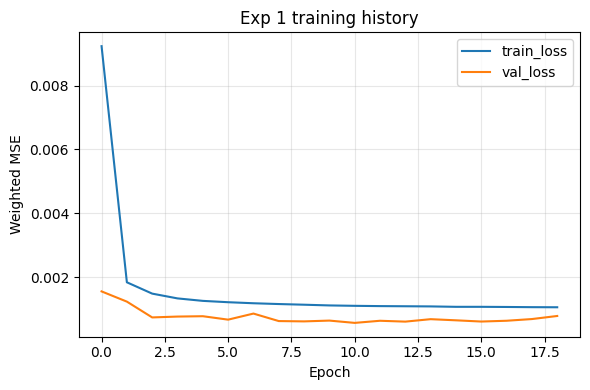


  --- Exp1_0.2% (rate_mult=3.430, threshold=0.004387) ---
  Precision=0.1279  Recall=0.4400  F1=0.1982  FPR=0.0060  FNR=0.5600  AUC=0.9908

Confusion matrix - Exp1_0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49600            300
Actual: Attack              56             44


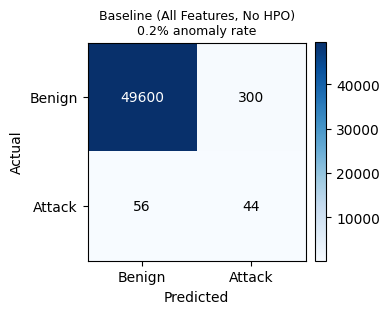


  --- Exp1_1% (rate_mult=2.004, threshold=0.003438) ---
  Precision=0.3912  Recall=0.7840  F1=0.5220  FPR=0.0123  FNR=0.2160  AUC=0.9912

Confusion matrix - Exp1_1%
                  Pred: Benign   Pred: Attack
Actual: Benign           48890            610
Actual: Attack             108            392


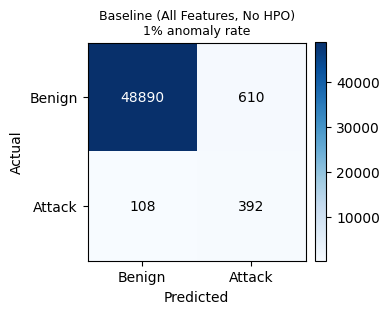


  --- Exp1_5% (rate_mult=1.474, threshold=0.002483) ---
  Precision=0.6764  Recall=0.9968  F1=0.8060  FPR=0.0251  FNR=0.0032  AUC=0.9911

Confusion matrix - Exp1_5%
                  Pred: Benign   Pred: Attack
Actual: Benign           46308           1192
Actual: Attack               8           2492


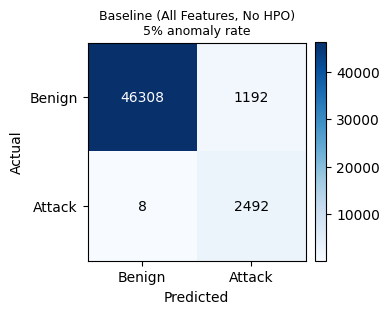


  Saved model + artifacts to: /content/ae_models_v2/exp1


,Experiment,ExperimentName,TestSet,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
0,1,"Baseline (All Features, No HPO)",0.2%,False,False,78,3.430366,0.004387,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.127907,0.4400,0.198198,0.006012,0.5600,0.990829,44,300,56,49600
1,1,"Baseline (All Features, No HPO)",1%,False,False,78,2.003652,0.003438,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.391218,0.7840,0.521971,0.012323,0.2160,0.991179,392,610,108,48890
2,1,"Baseline (All Features, No HPO)",5%,False,False,78,1.473613,0.002483,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.676439,0.9968,0.805951,0.025095,0.0032,0.991127,2492,1192,8,46308



EXPERIMENT 2: Feature-Selected (No HPO)
  Top 35 features by mutual information selected.
  Using 35 feature(s).
  [train (pre-transform)] 34/35 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (783444, 35)
  Using default params (no HPO): {'encoding_dim': 16, 'hidden_dim': 64, 'n_hidden_layers': 1, 'learning_rate': 0.001, 'dropout': 0.1, 'l2_reg': 1e-05}


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,219 (28.20 KB)

 Trainable params: 6,963 (27.20 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 0.0066 - val_loss: 0.0013
Epoch 2/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0019 - val_loss: 9.2538e-04
Epoch 3/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0015 - val_loss: 8.5158e-04
Epoch 4/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0014 - val_loss: 7.8973e-04
Epoch 5/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0013 - val_loss: 7.3776e-04
Epoch 6/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0012 - val_loss: 5.6399e-04
Epoch 7/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0012 - val_loss: 4.9437e-04
Epoch 8/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0012 - val_loss: 4.8652e-04
Epoch 9/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0011 - val_loss: 5.1391e-04
Epoch 10/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0011 - val_loss: 4.6375e-04
Epoch 11/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0011 - val_

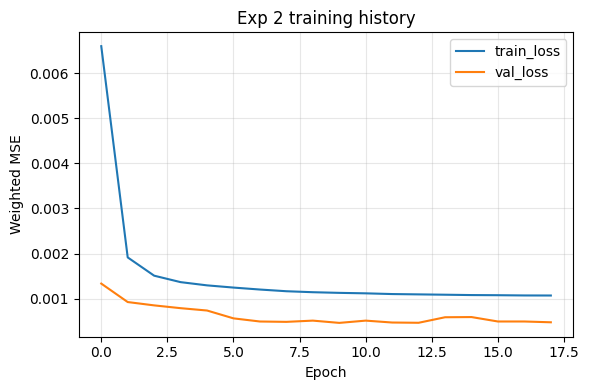


  --- Exp2_0.2% (rate_mult=4.000, threshold=0.003338) ---
  Precision=0.0500  Recall=0.2000  F1=0.0800  FPR=0.0076  FNR=0.8000  AUC=0.9908

Confusion matrix - Exp2_0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49520            380
Actual: Attack              80             20


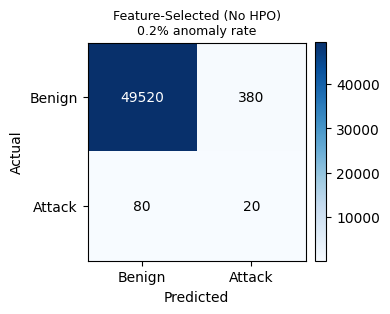


  --- Exp2_1% (rate_mult=2.724, threshold=0.001707) ---
  Precision=0.3668  Recall=1.0000  F1=0.5368  FPR=0.0174  FNR=0.0000  AUC=0.9911

Confusion matrix - Exp2_1%
                  Pred: Benign   Pred: Attack
Actual: Benign           48637            863
Actual: Attack               0            500


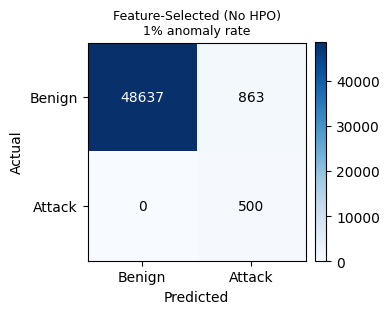


  --- Exp2_5% (rate_mult=1.264, threshold=0.001815) ---
  Precision=0.7604  Recall=0.9612  F1=0.8491  FPR=0.0159  FNR=0.0388  AUC=0.9909

Confusion matrix - Exp2_5%
                  Pred: Benign   Pred: Attack
Actual: Benign           46743            757
Actual: Attack              97           2403


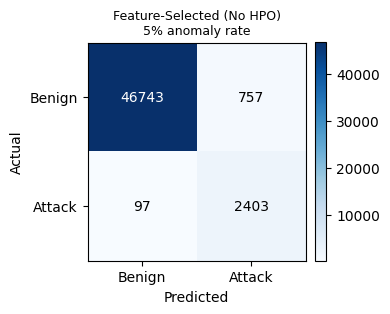


  Saved model + artifacts to: /content/ae_models_v2/exp2


,Experiment,ExperimentName,TestSet,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
0,2,Feature-Selected (No HPO),0.2%,True,False,35,4.000000,0.003338,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.050000,0.2000,0.080000,0.007615,0.8000,0.990788,20,380,80,49520
1,2,Feature-Selected (No HPO),1%,True,False,35,2.724340,0.001707,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.366838,1.0000,0.536769,0.017434,0.0000,0.991107,500,863,0,48637
2,2,Feature-Selected (No HPO),5%,True,False,35,1.263758,0.001815,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.760443,0.9612,0.849117,0.015937,0.0388,0.990946,2403,757,97,46743



EXPERIMENT 3: Optimized (All Features, With HPO)
  Using 78 feature(s).
  [train (pre-transform)] 66/78 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (783444, 78)


  [Optuna:exp3] best composite score=0.9336
  [Optuna:exp3] best params={'encoding_dim': 48, 'hidden_dim': 256, 'n_hidden_layers': 1, 'learning_rate': 0.0010683634092672745, 'dropout': 0.1844707023078049, 'l2_reg': 2.935415345389778e-07}


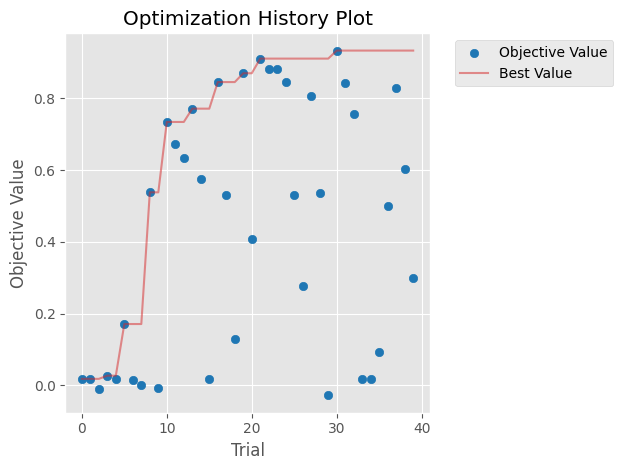

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 48)             │        12,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 78)             │        20,046 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,198 (262.49 KB)

 Trainable params: 66,174 (258.49 KB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0048 - val_loss: 5.0328e-04
Epoch 2/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 7.6595e-04 - val_loss: 3.5201e-04
Epoch 3/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 6.1874e-04 - val_loss: 2.4662e-04
Epoch 4/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 5.4187e-04 - val_loss: 2.4242e-04
Epoch 5/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 4.9696e-04 - val_loss: 2.1720e-04
Epoch 6/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 4.6991e-04 - val_loss: 2.3388e-04
Epoch 7/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 4.5295e-04 - val_loss: 2.0357e-04
Epoch 8/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 4.4053e-04 - val_loss: 2.5187e-04
Epoch 9/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 4.2651e-04 - val_loss: 2.2903e-04
Epoch 10/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 4.2238e-04 - val_loss: 3.4812e-04
Epoch 11/80
2755/2755 ━━━━━━━━━━━━━━

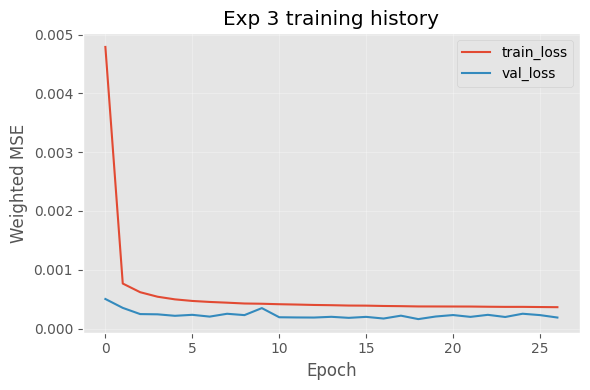


  --- Exp3_0.2% (rate_mult=2.724, threshold=0.001541) ---
  Precision=0.3590  Recall=0.9800  F1=0.5255  FPR=0.0035  FNR=0.0200  AUC=0.9983

Confusion matrix - Exp3_0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49725            175
Actual: Attack               2             98


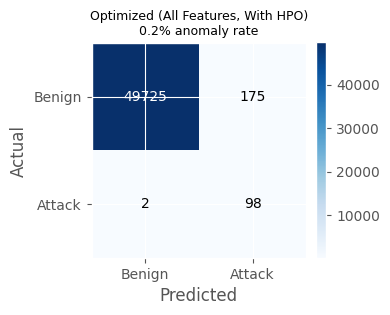


  --- Exp3_1% (rate_mult=1.264, threshold=0.001546) ---
  Precision=0.7294  Recall=0.9220  F1=0.8145  FPR=0.0035  FNR=0.0780  AUC=0.9984

Confusion matrix - Exp3_1%
                  Pred: Benign   Pred: Attack
Actual: Benign           49329            171
Actual: Attack              39            461


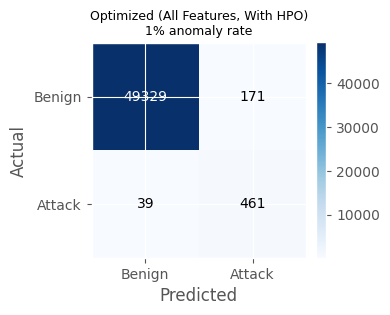


  --- Exp3_5% (rate_mult=1.084, threshold=0.001404) ---
  Precision=0.9225  Recall=1.0000  F1=0.9597  FPR=0.0044  FNR=0.0000  AUC=0.9983

Confusion matrix - Exp3_5%
                  Pred: Benign   Pred: Attack
Actual: Benign           47290            210
Actual: Attack               0           2500


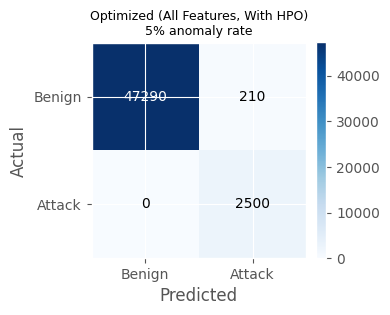


  Saved model + artifacts to: /content/ae_models_v2/exp3


,Experiment,ExperimentName,TestSet,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
0,3,"Optimized (All Features, With HPO)",0.2%,False,True,78,2.724340,0.001541,"{""encoding_dim"": 48, ""hidden_dim"": 256, ""n_hid...",0.358974,0.980,0.525469,0.003507,0.020,0.998328,98,175,2,49725
1,3,"Optimized (All Features, With HPO)",1%,False,True,78,1.263758,0.001546,"{""encoding_dim"": 48, ""hidden_dim"": 256, ""n_hid...",0.729430,0.922,0.814488,0.003455,0.078,0.998358,461,171,39,49329
2,3,"Optimized (All Features, With HPO)",5%,False,True,78,1.083788,0.001404,"{""encoding_dim"": 48, ""hidden_dim"": 256, ""n_hid...",0.922509,1.000,0.959693,0.004421,0.000,0.998309,2500,210,0,47290



EXPERIMENT 4: Optimized Feature-Selected (With HPO)
  Top 35 features by mutual information selected.
  Using 35 feature(s).
  [train (pre-transform)] 34/35 features have |skew|>0.75 before transform
  Transforming training data in chunks...
  Training array ready: (783444, 35)
  [Optuna:exp4] best composite score=0.7829
  [Optuna:exp4] best params={'encoding_dim': 24, 'hidden_dim': 256, 'n_hidden_layers': 1, 'learning_rate': 0.0006422315437929134, 'dropout': 0.039378399995746605, 'l2_reg': 6.405591954321014e-06}


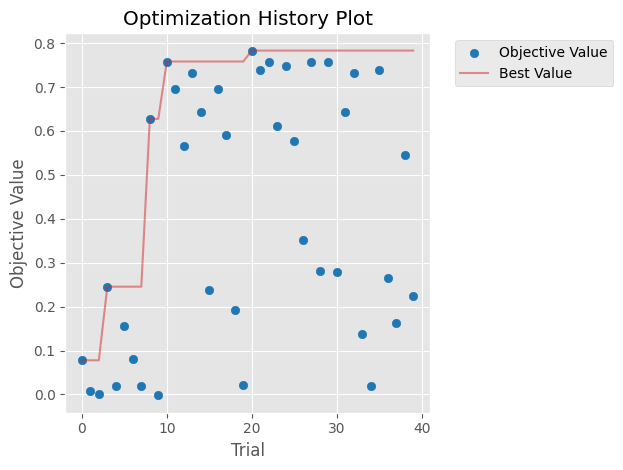

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 24)             │         6,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 35)             │         8,995 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,827 (128.23 KB)

 Trainable params: 31,803 (124.23 KB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 0.0041 - val_loss: 9.0526e-04
Epoch 2/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 9.8128e-04 - val_loss: 4.5304e-04
Epoch 3/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 5.8261e-04 - val_loss: 3.6793e-04
Epoch 4/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 4.4636e-04 - val_loss: 3.0702e-04
Epoch 5/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.8559e-04 - val_loss: 3.7520e-04
Epoch 6/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.5149e-04 - val_loss: 2.9757e-04
Epoch 7/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 3.3171e-04 - val_loss: 3.0129e-04
Epoch 8/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.1992e-04 - val_loss: 2.3826e-04
Epoch 9/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 3.0976e-04 - val_loss: 2.7143e-04
Epoch 10/80
2755/2755 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 3.0326e-04 - val_loss: 2.4045e-04
Epoch 11/80
2755/2755 ━━━━━━━━━━━━

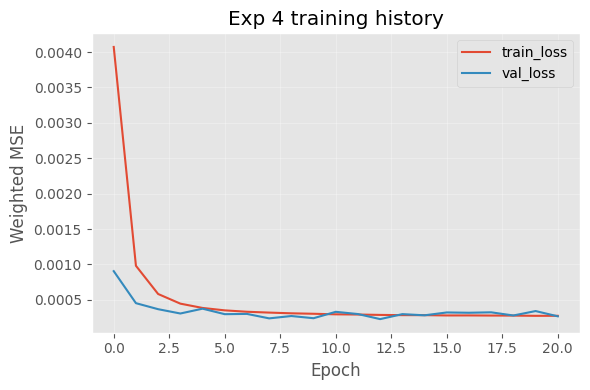


  --- Exp4_0.2% (rate_mult=0.861, threshold=0.001820) ---
  Precision=0.6782  Recall=0.5900  F1=0.6310  FPR=0.0006  FNR=0.4100  AUC=0.9729

Confusion matrix - Exp4_0.2%
                  Pred: Benign   Pred: Attack
Actual: Benign           49872             28
Actual: Attack              41             59


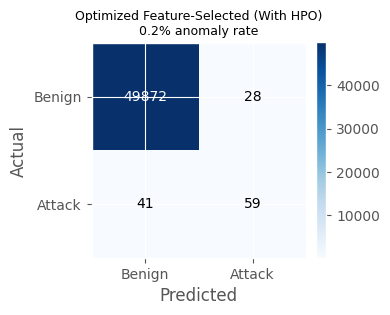


  --- Exp4_1% (rate_mult=0.738, threshold=0.001468) ---
  Precision=0.8973  Recall=0.6640  F1=0.7632  FPR=0.0008  FNR=0.3360  AUC=0.9764

Confusion matrix - Exp4_1%
                  Pred: Benign   Pred: Attack
Actual: Benign           49462             38
Actual: Attack             168            332


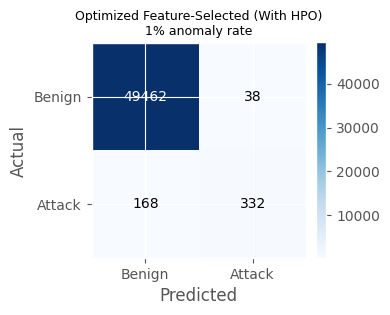


  --- Exp4_5% (rate_mult=0.684, threshold=0.001420) ---
  Precision=0.9766  Recall=0.6676  F1=0.7931  FPR=0.0008  FNR=0.3324  AUC=0.9765

Confusion matrix - Exp4_5%
                  Pred: Benign   Pred: Attack
Actual: Benign           47460             40
Actual: Attack             831           1669


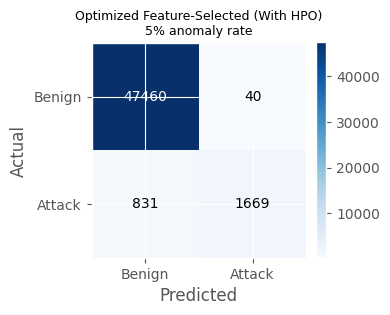


  Saved model + artifacts to: /content/ae_models_v2/exp4


,Experiment,ExperimentName,TestSet,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
0,4,Optimized Feature-Selected (With HPO),0.2%,True,True,35,0.860726,0.001820,"{""encoding_dim"": 24, ""hidden_dim"": 256, ""n_hid...",0.678161,0.5900,0.631016,0.000561,0.4100,0.972872,59,28,41,49872
1,4,Optimized Feature-Selected (With HPO),1%,True,True,35,0.738152,0.001468,"{""encoding_dim"": 24, ""hidden_dim"": 256, ""n_hid...",0.897297,0.6640,0.763218,0.000768,0.3360,0.976421,332,38,168,49462
2,4,Optimized Feature-Selected (With HPO),5%,True,True,35,0.683575,0.001420,"{""encoding_dim"": 24, ""hidden_dim"": 256, ""n_hid...",0.976594,0.6676,0.793062,0.000842,0.3324,0.976464,1669,40,831,47460


In [ ]:
# %% CELL 10-13 -- RUN ALL 4 EXPERIMENTS ------------------------------------
exp1_df = run_experiment(1, "Baseline (All Features, No HPO)", False, False)
display(exp1_df)

exp2_df = run_experiment(2, "Feature-Selected (No HPO)", True, False)
display(exp2_df)

exp3_df = run_experiment(3, "Optimized (All Features, With HPO)", False, True)
display(exp3_df)

exp4_df = run_experiment(4, "Optimized Feature-Selected (With HPO)", True, True)
display(exp4_df)

This cell displays the complete results DataFrame, providing a detailed overview of all metrics for each experiment and test set.

,Experiment,ExperimentName,TestSet,NumFeatures,Precision,Recall,F1,FPR,FNR,AUC
0,1,"Baseline (All Features, No HPO)",0.2%,78,0.127907,0.4400,0.198198,0.006012,0.5600,0.990829
1,1,"Baseline (All Features, No HPO)",1%,78,0.391218,0.7840,0.521971,0.012323,0.2160,0.991179
2,1,"Baseline (All Features, No HPO)",5%,78,0.676439,0.9968,0.805951,0.025095,0.0032,0.991127
3,2,Feature-Selected (No HPO),0.2%,35,0.050000,0.2000,0.080000,0.007615,0.8000,0.990788
4,2,Feature-Selected (No HPO),1%,35,0.366838,1.0000,0.536769,0.017434,0.0000,0.991107
5,2,Feature-Selected (No HPO),5%,35,0.760443,0.9612,0.849117,0.015937,0.0388,0.990946
6,3,"Optimized (All Features, With HPO)",0.2%,78,0.358974,0.9800,0.525469,0.003507,0.0200,0.998328
7,3,"Optimized (All Features, With HPO)",1%,78,0.729430,0.9220,0.814488,0.003455,0.0780,0.998358
8,3,"Optimized (All Features, With HPO)",5%,78,0.922509,1.0000,0.959693,0.004421,0.0000,0.998309
9,4,Optimized Feature-Selected (With HPO),0.2%,35,0.678161,0.5900,0.631016,0.000561,0.4100,0.972872


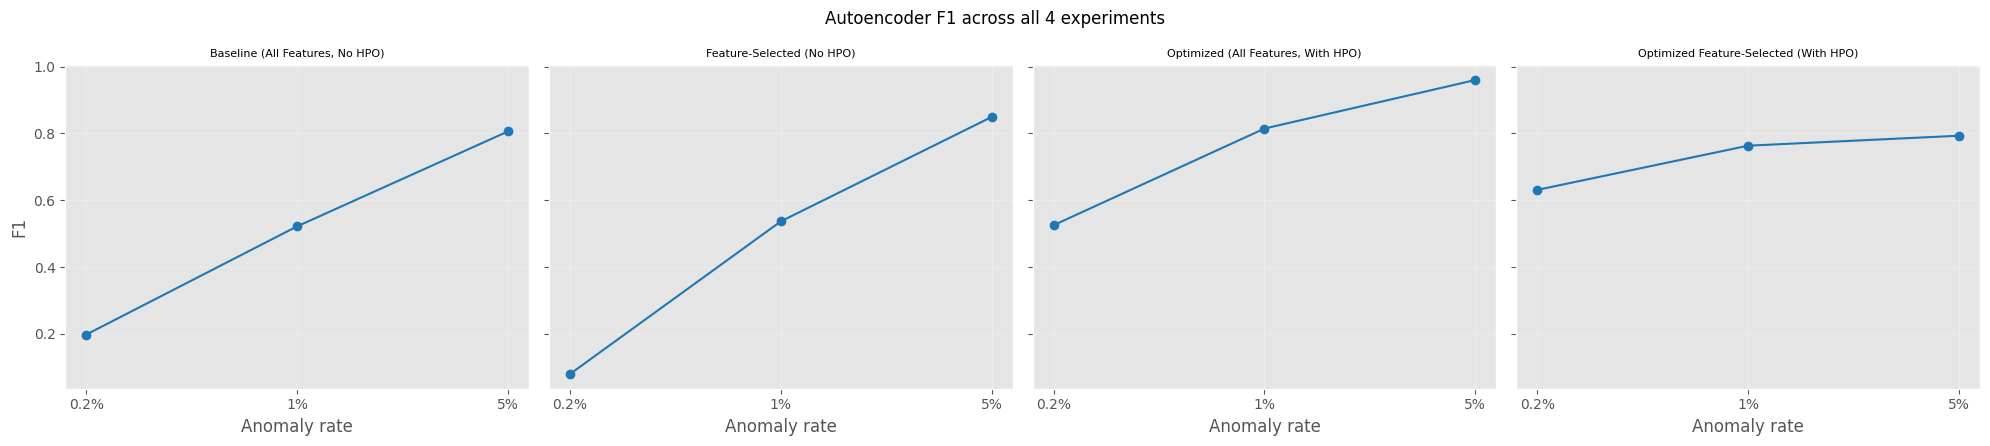

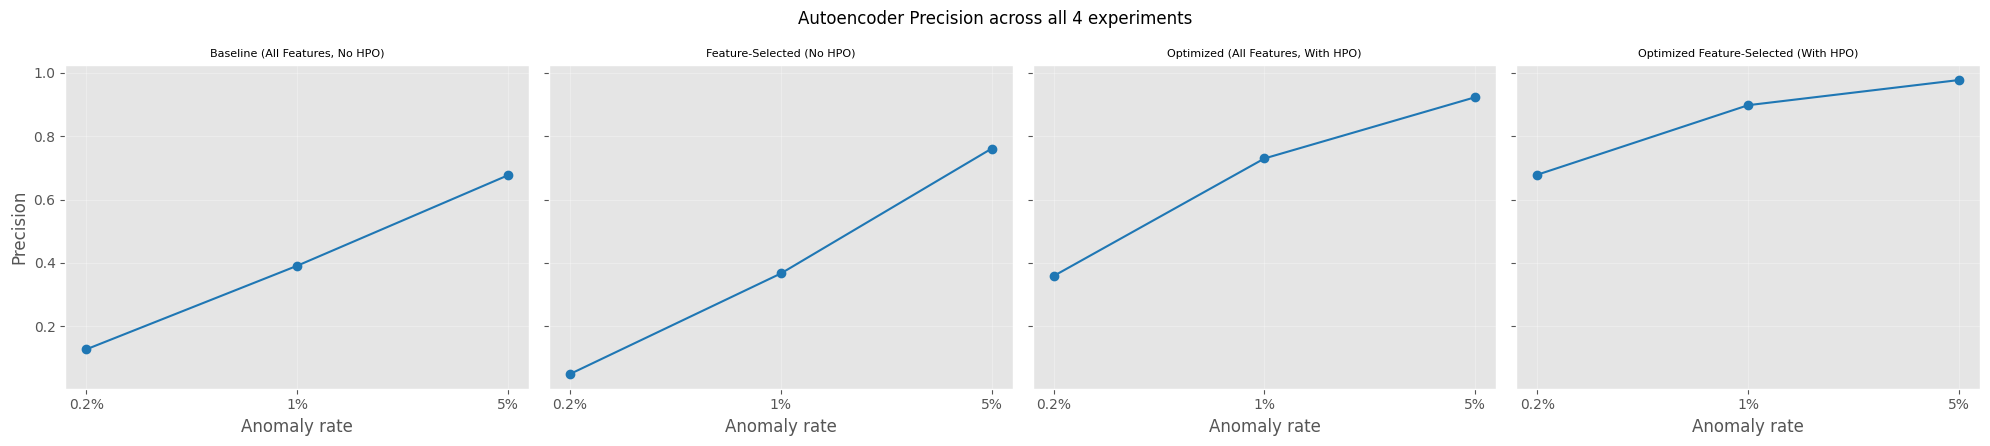

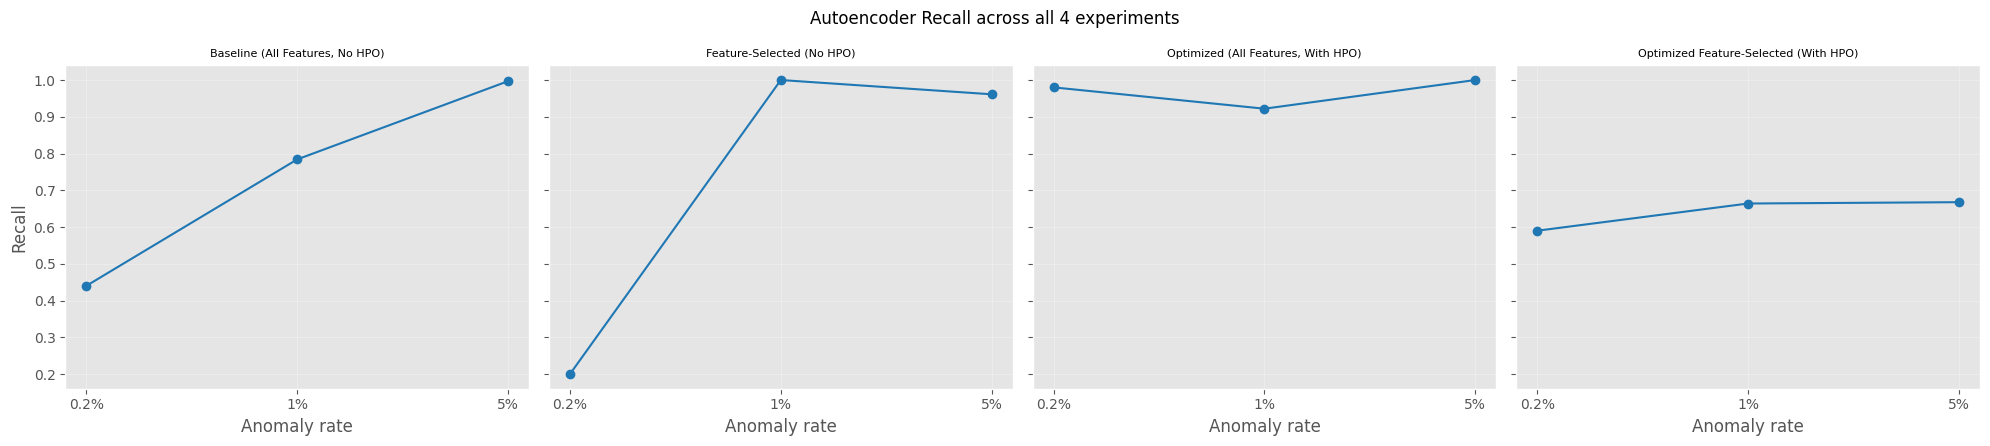

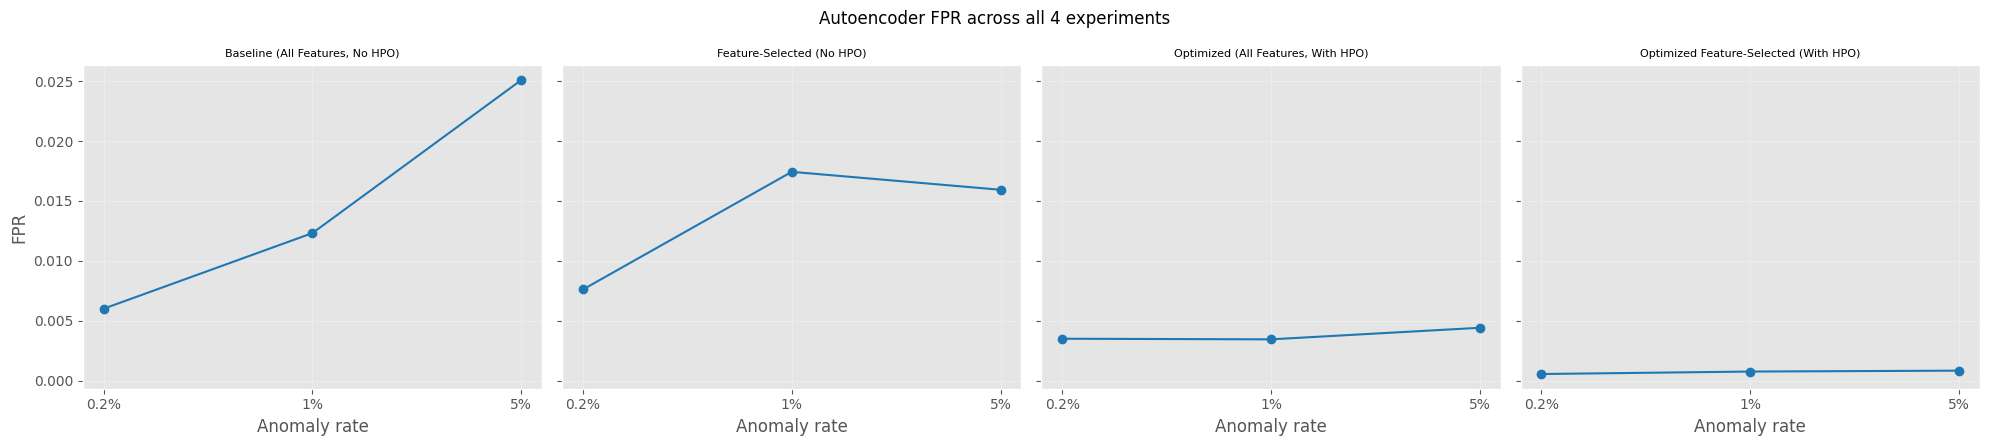

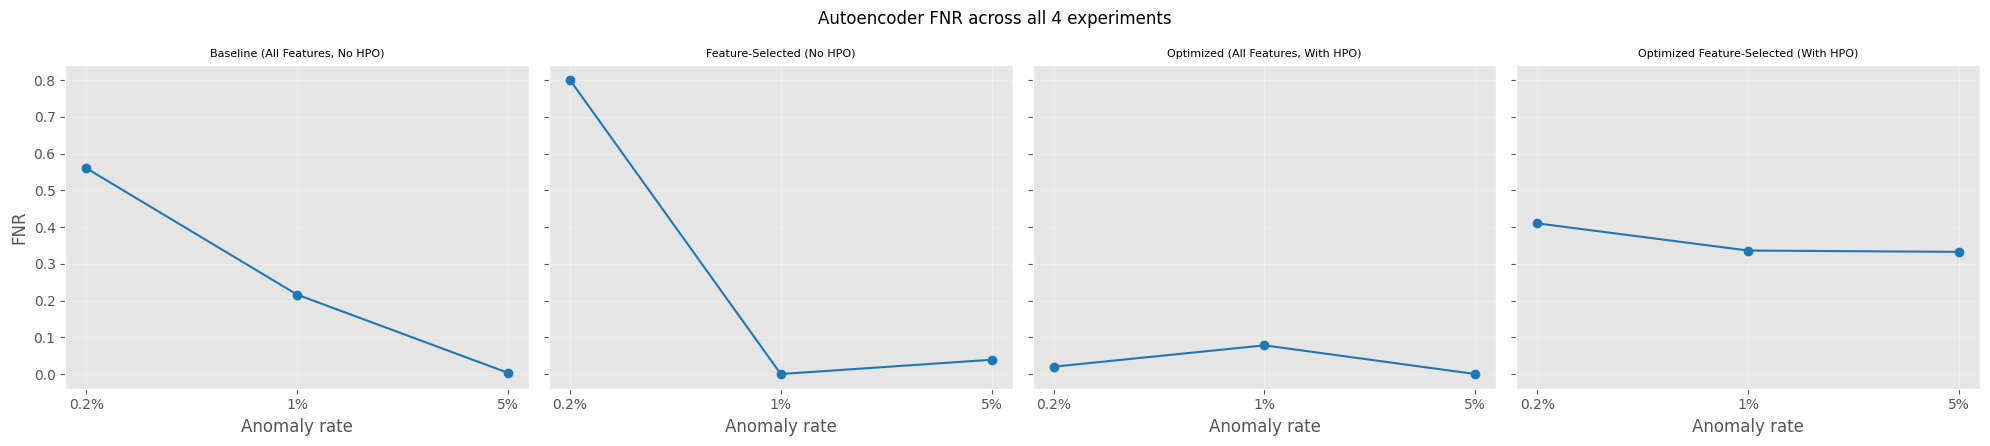

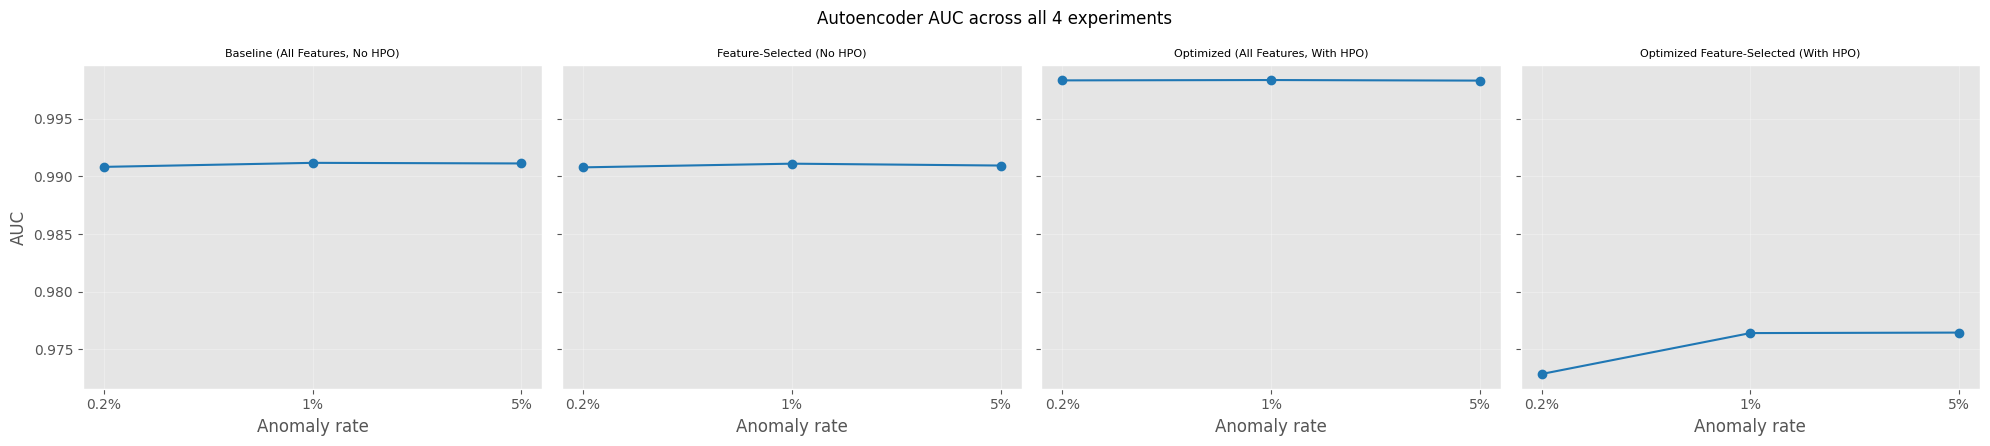


Best overall configuration (highest F1):


,Experiment,ExperimentName,TestSet,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
8,3,"Optimized (All Features, With HPO)",5%,False,True,78,1.083788,0.001404,"{""encoding_dim"": 48, ""hidden_dim"": 256, ""n_hid...",0.922509,1.0,0.959693,0.004421,0.0,0.998309,2500,210,0,47290


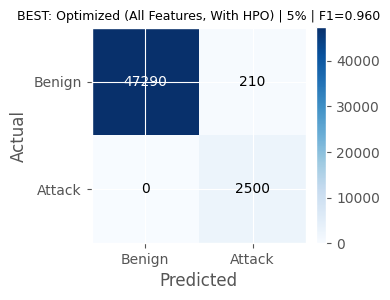


OBSERVATIONS
  0.2%: Optimized Feature-Selected (With HPO) F1=0.6310 Precision=0.6782 Recall=0.5900 FPR=0.0006 FNR=0.4100
  1%: Optimized (All Features, With HPO) F1=0.8145 Precision=0.7294 Recall=0.9220 FPR=0.0035 FNR=0.0780
  5%: Optimized (All Features, With HPO) F1=0.9597 Precision=0.9225 Recall=1.0000 FPR=0.0044 FNR=0.0000

-- Effect of feature selection (avg F1) --
SelectedFeatures
False    0.637628
True     0.608864
Name: F1, dtype: float64

-- Effect of HPO (avg F1) --
HPO
False    0.498668
True     0.747824
Name: F1, dtype: float64


TestSet,0.2%,1%,5%,F1_drop
ExperimentName,,,,
Optimized Feature-Selected (With HPO),0.631016,0.763218,0.793062,0.162046
"Optimized (All Features, With HPO)",0.525469,0.814488,0.959693,0.434224
"Baseline (All Features, No HPO)",0.198198,0.521971,0.805951,0.607753
Feature-Selected (No HPO),0.080000,0.536769,0.849117,0.769117



All 4 models saved under: /content/ae_models_v2/exp{1,2,3,4}/


In [ ]:
# %% CELL 14 -- MASTER COMPARISON -------------------------------------------
results_df = pd.DataFrame(ALL_RESULTS)
results_df.to_csv(os.path.join(SAVE_DIR, "all_experiments_results.csv"), index=False)
display(results_df[["Experiment", "ExperimentName", "TestSet", "NumFeatures",
                     "Precision", "Recall", "F1", "FPR", "FNR", "AUC"]])

def plot_metric_lines(results_df, metric):
    test_order = ["0.2%", "1%", "5%"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
    for i, exp_id in enumerate([1, 2, 3, 4]):
        ax = axes[i]
        sub = results_df[results_df["Experiment"] == exp_id].set_index("TestSet").reindex(test_order)
        ax.plot(test_order, sub[metric], marker="o", color="tab:blue")
        ax.set_title(sub["ExperimentName"].iloc[0], fontsize=8)
        ax.set_xlabel("Anomaly rate")
        if i == 0:
            ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
    fig.suptitle(f"Autoencoder {metric} across all 4 experiments")
    plt.tight_layout(); plt.show()

for metric in ["F1", "Precision", "Recall", "FPR", "FNR", "AUC"]:
    plot_metric_lines(results_df, metric)

best_row = results_df.loc[results_df["F1"].idxmax()]
print("\nBest overall configuration (highest F1):")
display(pd.DataFrame([best_row]))
key = (best_row["Experiment"], best_row["TestSet"])
if key in ALL_RAW_PREDS:
    y_true, y_pred = ALL_RAW_PREDS[key]
    plot_confusion(y_true, y_pred, f"BEST: {best_row['ExperimentName']} | {best_row['TestSet']} | F1={best_row['F1']:.3f}")

print("\n" + "="*78 + "\nOBSERVATIONS\n" + "="*78)
for name in ["0.2%", "1%", "5%"]:
    sub = results_df[results_df["TestSet"] == name]
    best = sub.loc[sub["F1"].idxmax()]
    print(f"  {name}: {best['ExperimentName']} F1={best['F1']:.4f} Precision={best['Precision']:.4f} "
          f"Recall={best['Recall']:.4f} FPR={best['FPR']:.4f} FNR={best['FNR']:.4f}")
print("\n-- Effect of feature selection (avg F1) --")
print(results_df.groupby("SelectedFeatures")["F1"].mean())
print("\n-- Effect of HPO (avg F1) --")
print(results_df.groupby("HPO")["F1"].mean())
pivot = results_df.pivot_table(index="ExperimentName", columns="TestSet", values="F1")
if {"5%", "0.2%"}.issubset(pivot.columns):
    pivot["F1_drop"] = pivot["5%"] - pivot["0.2%"]
    display(pivot.sort_values("F1_drop"))
print(f"\nAll 4 models saved under: {SAVE_DIR}/exp{{1,2,3,4}}/")

This cell displays a selection of key metrics (Precision, Recall, F1, FPR, FNR) from the `results_df`, focusing on the most relevant performance indicators for quick comparison.

In [ ]:
display(results_df)

,Experiment,ExperimentName,TestSet,SelectedFeatures,HPO,NumFeatures,RateMultiplier,Threshold,BestParams,Precision,Recall,F1,FPR,FNR,AUC,TP,FP,FN,TN
0,1,"Baseline (All Features, No HPO)",0.2%,False,False,78,3.430366,0.004387,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.127907,0.4400,0.198198,0.006012,0.5600,0.990829,44,300,56,49600
1,1,"Baseline (All Features, No HPO)",1%,False,False,78,2.003652,0.003438,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.391218,0.7840,0.521971,0.012323,0.2160,0.991179,392,610,108,48890
2,1,"Baseline (All Features, No HPO)",5%,False,False,78,1.473613,0.002483,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.676439,0.9968,0.805951,0.025095,0.0032,0.991127,2492,1192,8,46308
3,2,Feature-Selected (No HPO),0.2%,True,False,35,4.000000,0.003338,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.050000,0.2000,0.080000,0.007615,0.8000,0.990788,20,380,80,49520
4,2,Feature-Selected (No HPO),1%,True,False,35,2.724340,0.001707,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.366838,1.0000,0.536769,0.017434,0.0000,0.991107,500,863,0,48637
5,2,Feature-Selected (No HPO),5%,True,False,35,1.263758,0.001815,"{""encoding_dim"": 16, ""hidden_dim"": 64, ""n_hidd...",0.760443,0.9612,0.849117,0.015937,0.0388,0.990946,2403,757,97,46743
6,3,"Optimized (All Features, With HPO)",0.2%,False,True,78,2.724340,0.001541,"{""encoding_dim"": 48, ""hidden_dim"": 256, ""n_hid...",0.358974,0.9800,0.525469,0.003507,0.0200,0.998328,98,175,2,49725
7,3,"Optimized (All Features, With HPO)",1%,False,True,78,1.263758,0.001546,"{""encoding_dim"": 48, ""hidden_dim"": 256, ""n_hid...",0.729430,0.9220,0.814488,0.003455,0.0780,0.998358,461,171,39,49329
8,3,"Optimized (All Features, With HPO)",5%,False,True,78,1.083788,0.001404,"{""encoding_dim"": 48, ""hidden_dim"": 256, ""n_hid...",0.922509,1.0000,0.959693,0.004421,0.0000,0.998309,2500,210,0,47290
9,4,Optimized Feature-Selected (With HPO),0.2%,True,True,35,0.860726,0.001820,"{""encoding_dim"": 24, ""hidden_dim"": 256, ""n_hid...",0.678161,0.5900,0.631016,0.000561,0.4100,0.972872,59,28,41,49872


This cell visualizes the F1-scores of the different anomaly detection experiments across various anomaly rates (0.2%, 1.0%, and 5.0%). This plot helps in understanding the performance trends and identifying the most effective experimental configuration.

In [ ]:
display(results_df[["Experiment", "ExperimentName", "TestSet", "Precision", "Recall", "F1", "FPR", "FNR"]])

,Experiment,ExperimentName,TestSet,Precision,Recall,F1,FPR,FNR
0,1,"Baseline (All Features, No HPO)",0.2%,0.127907,0.4400,0.198198,0.006012,0.5600
1,1,"Baseline (All Features, No HPO)",1%,0.391218,0.7840,0.521971,0.012323,0.2160
2,1,"Baseline (All Features, No HPO)",5%,0.676439,0.9968,0.805951,0.025095,0.0032
3,2,Feature-Selected (No HPO),0.2%,0.050000,0.2000,0.080000,0.007615,0.8000
4,2,Feature-Selected (No HPO),1%,0.366838,1.0000,0.536769,0.017434,0.0000
5,2,Feature-Selected (No HPO),5%,0.760443,0.9612,0.849117,0.015937,0.0388
6,3,"Optimized (All Features, With HPO)",0.2%,0.358974,0.9800,0.525469,0.003507,0.0200
7,3,"Optimized (All Features, With HPO)",1%,0.729430,0.9220,0.814488,0.003455,0.0780
8,3,"Optimized (All Features, With HPO)",5%,0.922509,1.0000,0.959693,0.004421,0.0000
9,4,Optimized Feature-Selected (With HPO),0.2%,0.678161,0.5900,0.631016,0.000561,0.4100


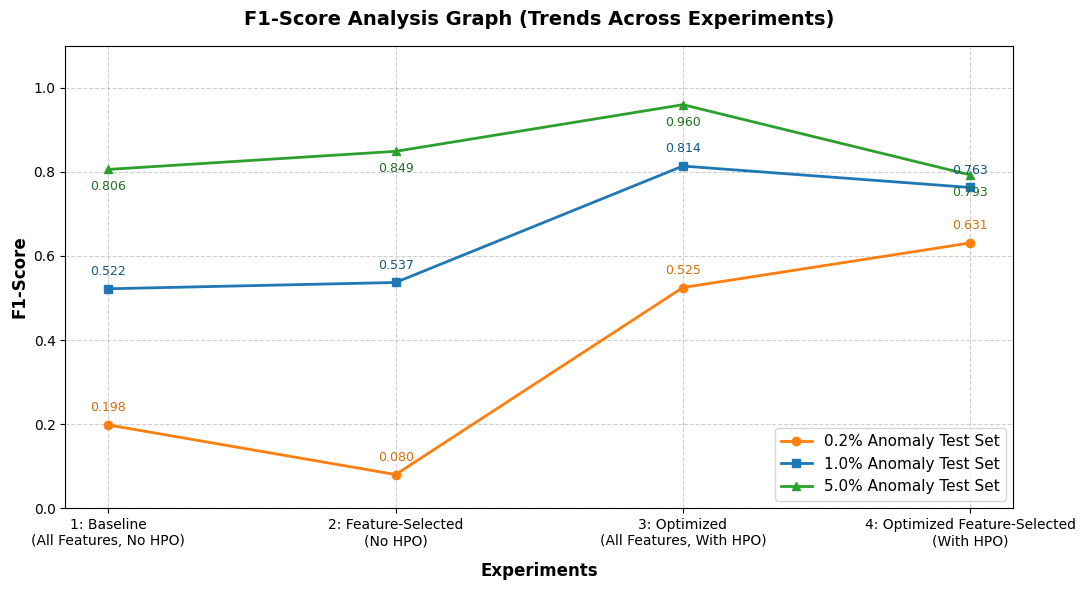

In [ ]:
import matplotlib.pyplot as plt

# Data from your anomaly detection experiments
experiments = [
    '1: Baseline\n(All Features, No HPO)',
    '2: Feature-Selected\n(No HPO)',
    '3: Optimized\n(All Features, With HPO)',
    '4: Optimized Feature-Selected\n(With HPO)'
]

f1_02 = [0.198, 0.080, 0.525, 0.631]  # 0.2% Anomaly Test Set
f1_1  = [0.522, 0.537, 0.814, 0.763]  # 1.0% Anomaly Test Set
f1_5  = [0.806, 0.849, 0.960, 0.793]  # 5.0% Anomaly Test Set

plt.figure(figsize=(11, 6))

# Plot lines with distinct colors, markers, and line styles
plt.plot(experiments, f1_02, marker='o', linewidth=2, color='#ff7f0e', label='0.2% Anomaly Test Set')
plt.plot(experiments, f1_1,  marker='s', linewidth=2, color='#1f77b4', label='1.0% Anomaly Test Set')
plt.plot(experiments, f1_5,  marker='^', linewidth=2, color='#2ca02c', label='5.0% Anomaly Test Set')

# Styling the graph
plt.title('F1-Score Analysis Graph (Trends Across Experiments)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Experiments', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)

# Annotating data points for clarity
for i in range(len(experiments)):
    plt.annotate(f"{f1_02[i]:.3f}", (experiments[i], f1_02[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='#d66f0a')
    plt.annotate(f"{f1_1[i]:.3f}", (experiments[i], f1_1[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='#165582')
    plt.annotate(f"{f1_5[i]:.3f}", (experiments[i], f1_5[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='#1e6e1e')

plt.tight_layout()
plt.show()